In [2]:
import pandas as pd

In [3]:
results = pd.read_csv('evaluation_results.csv')
results.head()

,Unnamed: 0,churn_0_LPIPS,churn_0_EDMCLIP,churn_0_DMDCLIP,churn_1_LPIPS,churn_1_EDMCLIP,churn_1_DMDCLIP,churn_10_LPIPS,churn_10_EDMCLIP,churn_10_DMDCLIP,churn_40_LPIPS,churn_40_EDMCLIP,churn_40_DMDCLIP,churn_5_LPIPS,churn_5_EDMCLIP,churn_5_DMDCLIP
0,0,0.418465,0.275146,0.306885,0.439853,0.266357,0.306885,0.586870,0.283203,0.306885,0.580925,0.292725,0.306885,0.594465,0.286621,0.306885
1,1,0.606687,0.360840,0.255127,0.681710,0.286377,0.255127,0.746863,0.297607,0.255127,0.756145,0.313721,0.255127,0.715188,0.318604,0.255127
2,2,0.570885,0.237671,0.273438,0.576079,0.281006,0.273438,0.611480,0.232178,0.273438,0.696785,0.202637,0.273438,0.647657,0.218994,0.273438
3,3,0.519314,0.329346,0.189941,0.599542,0.278809,0.189941,0.739417,0.269287,0.189941,0.806064,0.305176,0.189941,0.713420,0.254883,0.189941
4,4,0.321650,0.270996,0.282471,0.399835,0.263184,0.282471,0.540544,0.275146,0.282471,0.584756,0.265869,0.282471,0.499350,0.266846,0.282471


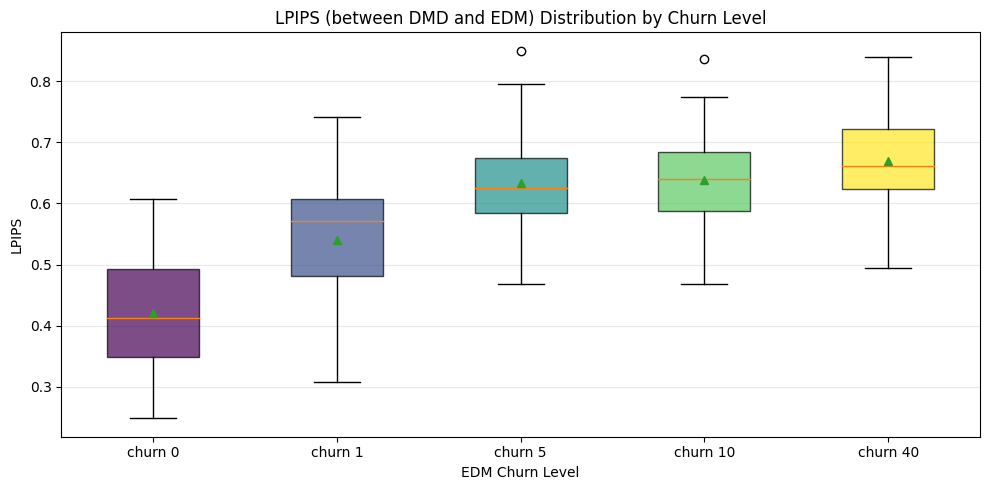

In [5]:
import matplotlib.pyplot as plt

lpips_cols = [c for c in results.columns if c.endswith('_LPIPS')]
# Sort by churn number
lpips_cols.sort(key=lambda c: int(c.split('_')[1]))

# Exclude MEAN/STD rows
data = results[~results['Unnamed: 0'].isin(['MEAN', 'STD'])]

fig, ax = plt.subplots(figsize=(10, 5))
box_data = [data[col].astype(float) for col in lpips_cols]
labels = [col.replace('_LPIPS', '').replace('churn_', 'churn ') for col in lpips_cols]

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)

colors = plt.cm.viridis([i / (len(lpips_cols) - 1) for i in range(len(lpips_cols))])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('EDM Churn Level')
ax.set_ylabel('LPIPS')
ax.set_title('LPIPS (between DMD and EDM) Distribution by Churn Level')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

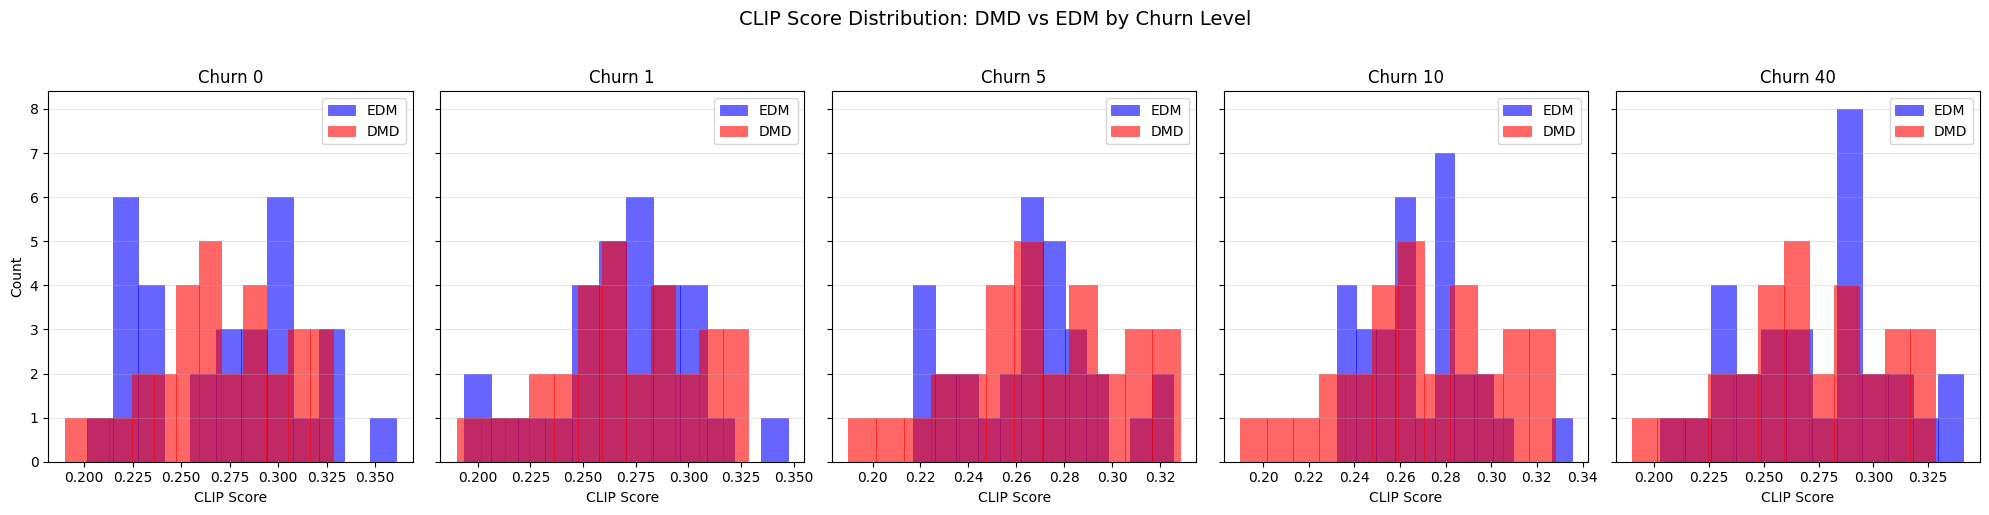

In [4]:
churn_levels = sorted(
    set(c.split('_')[1] for c in results.columns if c.startswith('churn_') and c.endswith('CLIP')),
    key=int,
)

fig, axes = plt.subplots(1, len(churn_levels), figsize=(4 * len(churn_levels), 5), sharey=True)

for ax, churn in zip(axes, churn_levels):
    edm_col = f'churn_{churn}_EDMCLIP'
    dmd_col = f'churn_{churn}_DMDCLIP'
    edm_vals = data[edm_col].astype(float)
    dmd_vals = data[dmd_col].astype(float)

    ax.hist(edm_vals, bins=12, alpha=0.6, color='blue', label='EDM', edgecolor='blue', linewidth=0.5)
    ax.hist(dmd_vals, bins=12, alpha=0.6, color='red', label='DMD', edgecolor='red', linewidth=0.5)

    ax.set_title(f'Churn {churn}')
    ax.set_xlabel('CLIP Score')
    if ax is axes[0]:
        ax.set_ylabel('Count')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('CLIP Score Distribution: DMD vs EDM by Churn Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()